Part A — Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv('customer_churn_data.csv')

2. Load and Understand the Data

In [2]:
#  first 5 rows
df.head()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [3]:
#  last 5 rows
df.tail()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


In [4]:
# number of rows and columns
df.shape

(1220, 17)

In [5]:
# colunn names
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'tenure_months',
       'monthly_charges', 'total_charges', 'contract_type', 'internet_service',
       'tech_support', 'online_security', 'paperless_billing',
       'payment_method', 'num_support_calls', 'late_payments_last_year',
       'avg_monthly_usage_gb', 'churn'],
      dtype='object')

In [6]:
# data type of each column
df.dtypes


customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

In [7]:
#  dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1220 non-null   object 
 1   age                      1220 non-null   int64  
 2   gender                   1220 non-null   object 
 3   region                   1220 non-null   object 
 4   tenure_months            1220 non-null   int64  
 5   monthly_charges          1198 non-null   float64
 6   total_charges            1187 non-null   float64
 7   contract_type            1220 non-null   object 
 8   internet_service         1220 non-null   object 
 9   tech_support             1194 non-null   object 
 10  online_security          1199 non-null   object 
 11  paperless_billing        1220 non-null   object 
 12  payment_method           1200 non-null   object 
 13  num_support_calls        1220 non-null   int64  
 14  late_payments_last_year 

In [8]:
# descriptive statistics
df.describe()

,age,tenure_months,monthly_charges,total_charges,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
count,1220.000000,1220.000000,1198.000000,1187.000000,1220.000000,1220.000000,1196.000000
mean,49.309016,36.956557,66.509474,2421.133437,1.759836,1.143443,214.370569
std,18.125678,20.512560,24.295211,1681.896803,1.298902,1.078501,143.970148
min,18.000000,1.000000,18.000000,12.600000,0.000000,0.000000,0.000000
25%,34.000000,19.000000,50.047500,1011.740000,1.000000,0.000000,116.075000
50%,49.500000,38.000000,69.020000,2120.450000,2.000000,1.000000,206.300000
75%,65.000000,55.000000,86.465000,3619.765000,3.000000,2.000000,322.775000
max,80.000000,72.000000,118.580000,7579.280000,8.000000,6.000000,600.600000


3. Data Quality Checks

In [9]:
# missing values in every column
df.isnull().sum()


customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

<Axes: >

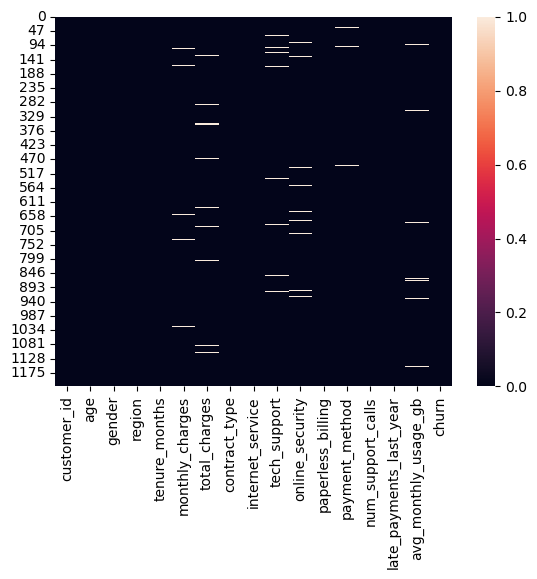

In [10]:
sns.heatmap(df.isnull())

In [11]:
# duplicate records
df.duplicated().sum()

np.int64(20)

In [12]:
# unique values in categorical columns
df.nunique()

customer_id                1200
age                          63
gender                        2
region                        4
tenure_months                72
monthly_charges            1065
total_charges              1165
contract_type                 3
internet_service              3
tech_support                  3
online_security               3
paperless_billing             2
payment_method                4
num_support_calls             9
late_payments_last_year       7
avg_monthly_usage_gb        884
churn                         2
dtype: int64

In [13]:
# class distribution of the churn target
df['churn'].value_counts()
# # correlation matrix
# df.corr()
# # heatmap of the correlation matrix
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
# plt.show()

churn
Yes    688
No     532
Name: count, dtype: int64

## 4. Data Cleaning


**Cleaning decisions (based on Section 3 findings):**

1. **Duplicate records:** There are 20 duplicate rows. I will **drop** them so the same customer is not counted twice during training.

2. **Missing numeric values:** `monthly_charges`, `total_charges`, and `avg_monthly_usage_gb` have missing values. I will fill them with the **median**, because median is less affected by outliers than the mean.

3. **Missing categorical values:** `tech_support`, `online_security`, and `payment_method` have missing values. I will fill them with the **mode** (most frequent value), which is suitable for categorical columns.

4. **`customer_id`:** This is only an identifier, not a behaviour feature. I will **remove** it so the model learns patterns instead of memorising IDs.


In [14]:
# remove duplicate records
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)


Duplicates before: 20
Duplicates after: 0
Shape after removing duplicates: (1200, 17)


In [15]:
# customer_id is only an identifier, not useful for prediction
df = df.drop("customer_id", axis=1)
df.head()


,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [16]:
# check mean median and mode for all missing numeric data
numeric_missing_cols = ["monthly_charges", "total_charges", "avg_monthly_usage_gb"]

for col in numeric_missing_cols:
    print(f"\n{col}")
    print("  mean  :", df[col].mean())
    print("  median:", df[col].median())
    print("  mode  :", df[col].mode()[0])



monthly_charges
  mean  : 66.56032230703985
  median: 69.27
  mode  : 18.0

total_charges
  mean  : 2422.769391602399
  median: 2120.45
  mode  : 12.6

avg_monthly_usage_gb
  mean  : 214.3494047619048
  median: 206.5
  mode  : 0.0


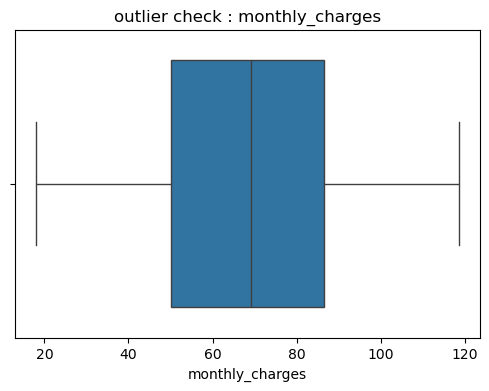

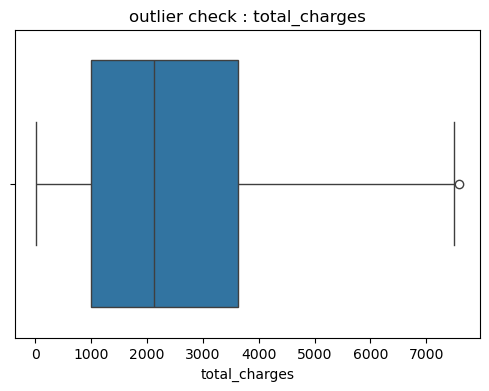

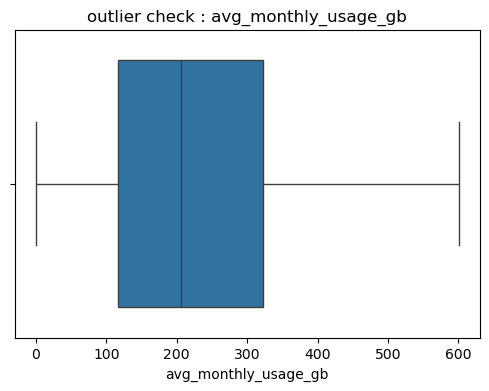

In [17]:
# visual outlier check for numeric columns with missing values

for col in ["monthly_charges", "total_charges", "avg_monthly_usage_gb"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'outlier check : {col}')
    plt.show



In [18]:
# fill missing numeric values with median
df["monthly_charges"].fillna(df["monthly_charges"].median(), inplace=True)
df["total_charges"].fillna(df["total_charges"].median(), inplace=True)
df["avg_monthly_usage_gb"].fillna(df["avg_monthly_usage_gb"].median(), inplace=True)


In [19]:
# fill missing categorical values with mode
df["tech_support"].fillna(df["tech_support"].mode()[0], inplace=True)
df["online_security"].fillna(df["online_security"].mode()[0], inplace=True)
df["payment_method"].fillna(df["payment_method"].mode()[0], inplace=True)


In [20]:
# check missing values after cleaning
df.isnull().sum()


age                        0
gender                     0
region                     0
tenure_months              0
monthly_charges            0
total_charges              0
contract_type              0
internet_service           0
tech_support               0
online_security            0
paperless_billing          0
payment_method             0
num_support_calls          0
late_payments_last_year    0
avg_monthly_usage_gb       0
churn                      0
dtype: int64

In [21]:
# final shape after cleaning
df.shape


(1200, 16)

## 5. Exploratory Data Analysis


### Churn class distribution


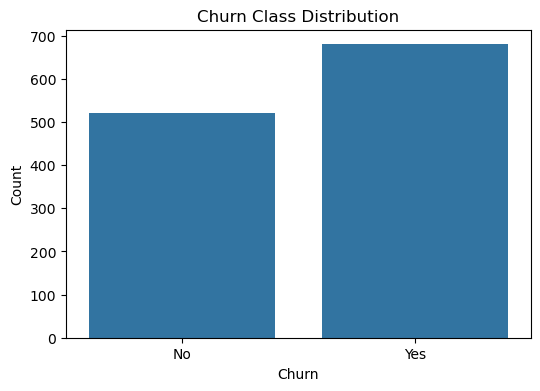

In [22]:
# churn class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn")
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


**Observation:** The dataset has more churned customers (Yes) than non-churned (No), but the gap is not extreme. Accuracy alone may still hide mistakes on one class, so Precision, Recall, and F1 should also be checked later.


### Churn by contract type


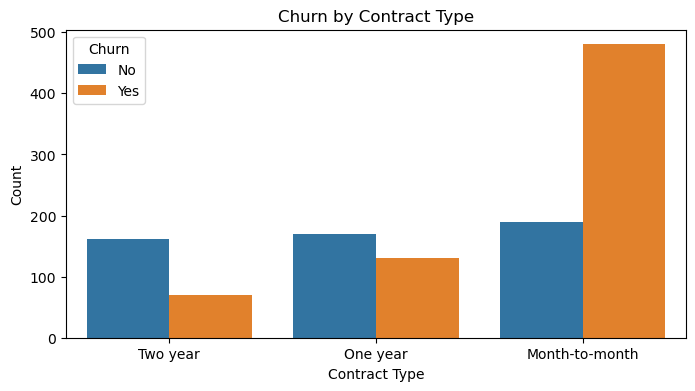

In [23]:
# churn by contract type
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="contract_type", hue="churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()


**Observation:** Month-to-month contracts usually show higher churn because customers can leave easily. Longer contracts (One year / Two year) often have lower churn.


### Churn by internet service


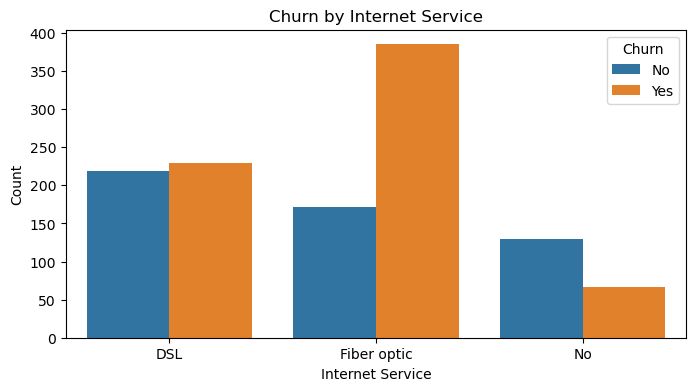

In [24]:
# churn by internet service
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="internet_service", hue="churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()


**Observation:** Fiber optic customers often churn more than DSL or No internet customers. This can be linked to higher bills or higher service expectations.


### Monthly charges distribution


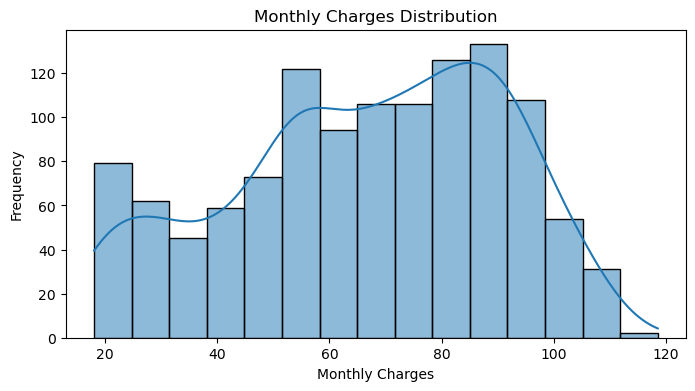

In [25]:
# monthly charges distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="monthly_charges", kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()


**Observation:** Monthly charges are spread across a wide range. Higher monthly bills can increase the chance of churn if customers feel they are not getting enough value.


### Tenure distribution


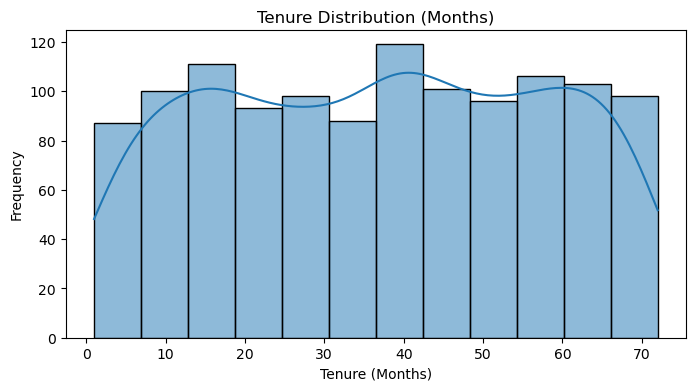

In [26]:
# tenure distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="tenure_months", kde=True)
plt.title("Tenure Distribution (Months)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()


**Observation:** Many customers have shorter tenure. Newer customers are often more likely to leave before they become loyal long-term users.


### Additional visualization: Late payments vs churn


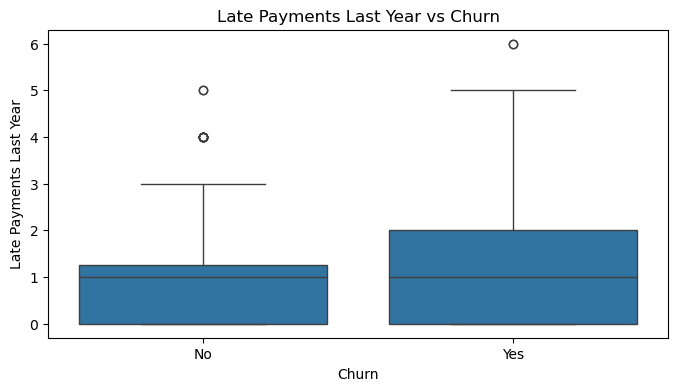

In [27]:
# additional visualization: late payments vs churn
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="churn", y="late_payments_last_year")
plt.title("Late Payments Last Year vs Churn")
plt.xlabel("Churn")
plt.ylabel("Late Payments Last Year")
plt.show()


**Observation:** Customers who churn tend to have more late payments. Payment problems are a useful early warning signal for churn risk.


In [28]:
# x input and y target
X = df.drop("churn", axis =1)
Y = df['churn']

In [29]:
X.head()

,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
0,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4
1,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3
2,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2
3,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5
4,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1


In [30]:
Y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: object

6. Prepare Features and Target

In [31]:
# numeric column
numeric_cols = X.select_dtypes(include=['number']).columns
print('Numeric columns:')
print(numeric_cols.tolist())

# categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print('\nCategorical Columns')
print(categorical_cols.tolist())

# 

Numeric columns:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb']

Categorical Columns
['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method']


7. Train-Test Split

In [32]:
# split data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

## 8. Preprocessing

I will use ColumnTransformer + Pipeline because numeric and categorical columns are handled separately,
and the same steps run at training time and in the Streamlit app.

- Numeric: median imputer + StandardScaler
- Categorical: most_frequent imputer + OneHotEncoder

In [33]:
# numeric pipeline: fill missing + scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical pipeline: fill missing + encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 9. Train At Least TWO Models
I will train:
1. Logistic Regression — simple, interpretable baseline
2. Random Forest — stronger model that can learn non-linear patterns

In [34]:
# 1. Logistic Regression pipeline
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, Y_train)
y_pred_log = log_reg.predict(X_test)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [35]:
# 2. Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, Y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully")

Random Forest trained successfully


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [37]:
# 3. Decision Tree pipeline
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, Y_train)
y_pred_dt = dt_model.predict(X_test)

print('Decision Tree trained successfully/n')

# Decision Tree metrics
print("=== Decision Tree ===")
print("Accuracy :", accuracy_score(Y_test, y_pred_dt))
print("Precision:", precision_score(Y_test, y_pred_dt, pos_label="Yes"))
print("Recall   :", recall_score(Y_test, y_pred_dt, pos_label="Yes"))
print("F1 Score :", f1_score(Y_test, y_pred_dt, pos_label="Yes"))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_dt))

Decision Tree trained successfully/n
=== Decision Tree ===
Accuracy : 0.6416666666666667
Precision: 0.6923076923076923
Recall   : 0.6617647058823529
F1 Score : 0.6766917293233082

Confusion Matrix:
 [[64 40]
 [46 90]]

Classification Report:
               precision    recall  f1-score   support

          No       0.58      0.62      0.60       104
         Yes       0.69      0.66      0.68       136

    accuracy                           0.64       240
   macro avg       0.64      0.64      0.64       240
weighted avg       0.64      0.64      0.64       240



In [38]:
# 4. KNN pipeline
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, Y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN trained successfully")

# KNN metrics
print("=== KNN ===")
print("Accuracy :", accuracy_score(Y_test, y_pred_knn))
print("Precision:", precision_score(Y_test, y_pred_knn, pos_label="Yes"))
print("Recall   :", recall_score(Y_test, y_pred_knn, pos_label="Yes"))
print("F1 Score :", f1_score(Y_test, y_pred_knn, pos_label="Yes"))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_knn))

KNN trained successfully
=== KNN ===
Accuracy : 0.6875
Precision: 0.6918238993710691
Recall   : 0.8088235294117647
F1 Score : 0.7457627118644068

Confusion Matrix:
 [[ 55  49]
 [ 26 110]]

Classification Report:
               precision    recall  f1-score   support

          No       0.68      0.53      0.59       104
         Yes       0.69      0.81      0.75       136

    accuracy                           0.69       240
   macro avg       0.69      0.67      0.67       240
weighted avg       0.69      0.69      0.68       240



In [39]:
# Support vector Machine# 5. Support Vector Machine pipeline
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

svm_model.fit(X_train, Y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM trained successfully")
# SVM metrics
print("=== Support Vector Machine ===")
print("Accuracy :", accuracy_score(Y_test, y_pred_svm))
print("Precision:", precision_score(Y_test, y_pred_svm, pos_label="Yes"))
print("Recall   :", recall_score(Y_test, y_pred_svm, pos_label="Yes"))
print("F1 Score :", f1_score(Y_test, y_pred_svm, pos_label="Yes"))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_svm))

SVM trained successfully
=== Support Vector Machine ===
Accuracy : 0.7208333333333333
Precision: 0.7412587412587412
Recall   : 0.7794117647058824
F1 Score : 0.7598566308243727

Confusion Matrix:
 [[ 67  37]
 [ 30 106]]

Classification Report:
               precision    recall  f1-score   support

          No       0.69      0.64      0.67       104
         Yes       0.74      0.78      0.76       136

    accuracy                           0.72       240
   macro avg       0.72      0.71      0.71       240
weighted avg       0.72      0.72      0.72       240




##10. Model Evaluation

In [40]:
# Logistic Regression metrics
print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(Y_test, y_pred_log))
print("Precision:", precision_score(Y_test, y_pred_log, pos_label="Yes"))
print("Recall   :", recall_score(Y_test, y_pred_log, pos_label="Yes"))
print("F1 Score :", f1_score(Y_test, y_pred_log, pos_label="Yes"))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_log))

=== Logistic Regression ===
Accuracy : 0.7583333333333333
Precision: 0.7671232876712328
Recall   : 0.8235294117647058
F1 Score : 0.7943262411347518

Confusion Matrix:
 [[ 70  34]
 [ 24 112]]

Classification Report:
               precision    recall  f1-score   support

          No       0.74      0.67      0.71       104
         Yes       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240



In [41]:
# Random Forest metrics
print("=== Random Forest ===")
print("Accuracy :", accuracy_score(Y_test, y_pred_rf))
print("Precision:", precision_score(Y_test, y_pred_rf, pos_label="Yes"))
print("Recall   :", recall_score(Y_test, y_pred_rf, pos_label="Yes"))
print("F1 Score :", f1_score(Y_test, y_pred_rf, pos_label="Yes"))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 0.7166666666666667
Precision: 0.7428571428571429
Recall   : 0.7647058823529411
F1 Score : 0.7536231884057971

Confusion Matrix:
 [[ 68  36]
 [ 32 104]]

Classification Report:
               precision    recall  f1-score   support

          No       0.68      0.65      0.67       104
         Yes       0.74      0.76      0.75       136

    accuracy                           0.72       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.72      0.72      0.72       240



In [42]:
# comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(Y_test, y_pred_log),
        accuracy_score(Y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(Y_test, y_pred_log, pos_label="Yes"),
        precision_score(Y_test, y_pred_rf, pos_label="Yes")
    ],
    "Recall": [
        recall_score(Y_test, y_pred_log, pos_label="Yes"),
        recall_score(Y_test, y_pred_rf, pos_label="Yes")
    ],
    "F1 Score": [
        f1_score(Y_test, y_pred_log, pos_label="Yes"),
        f1_score(Y_test, y_pred_rf, pos_label="Yes")
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.758333,0.767123,0.823529,0.794326
1,Random Forest,0.716667,0.742857,0.764706,0.753623


## 11. Select the Final Model

**Final model: Logistic Regression**

I did not choose based on training accuracy.
I compared both models on the **test set**.

Logistic Regression has higher Accuracy, Precision, Recall, and F1 than Random Forest.
For churn, Recall and F1 matter because we want to catch customers who may leave.
So I selected the Logistic Regression pipeline as the final model.

In [43]:
# final selected model
final_model = log_reg
print("Final model selected: Logistic Regression")

Final model selected: Logistic Regression


## 12. Save the Final Model
I save the complete Pipeline (preprocessor + Logistic Regression) as churn_pipeline.pkl
so the Streamlit app can load one file and predict without repeating cleaning/encoding steps.

In [44]:
# save complete preprocessing + model pipeline
joblib.dump(final_model, "churn_pipeline.pkl")
print("Model saved successfully as churn_pipeline.pkl")

Model saved successfully as churn_pipeline.pkl


## 13. Reload and Test the Saved Model

In [45]:
# reload saved pipeline
loaded_model = joblib.load("churn_pipeline.pkl")

# one manual test sample (same columns as X)
sample = X_test.iloc[[0]]
print("Sample input:")
display(sample)

prediction = loaded_model.predict(sample)[0]
print("Predicted churn:", prediction)

Sample input:


,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
1140,73,Male,North,19,42.43,758.01,Month-to-month,DSL,Yes,No,No,Mailed check,3,0,106.4


Predicted churn: Yes


In [46]:
# prediction probability/confidence
proba = loaded_model.predict_proba(sample)[0]
print("Probability No :", round(proba[0], 3))
print("Probability Yes:", round(proba[1], 3))

Probability No : 0.397
Probability Yes: 0.603
